In [2]:
import math
import time
import torch
import torch.nn as nn

In [3]:
class NaiveSelfAttentionBenchmark(nn.Module):
    """
    A simple, self-contained PyTorch module that implements standard (naive)
    self-attention. It records the intermediate attention weights matrix to
    demonstrate O(N^2) memory scaling.
    """
    def __init__(self, vocab_size, d_model=64, d_k=32):
        super().__init__()
        self.d_k = d_k
        
        # Trainable embedding layer
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=d_model)
        
        # Projection matrices for Query, Key, and Value
        self.W_Q = nn.Linear(d_model, d_k, bias=False)
        self.W_K = nn.Linear(d_model, d_k, bias=False)
        self.W_V = nn.Linear(d_model, d_k, bias=False)
        
        # Container to explicitly store intermediate weights for memory demonstration
        self.attn_weights = None
    def forward(self, x):
        # x shape: (seq_len)
        
        # 1. Token Embeddings: shape (seq_len, d_model)
        embeddings = self.embedding(x)
        
        # 2. Linear projections to Q, K, V: shape (seq_len, d_k)
        Q = self.W_Q(embeddings)
        K = self.W_K(embeddings)
        V = self.W_V(embeddings)
        
        # 3. Attention scores: (Q @ K^T) / sqrt(d_k)
        # shape: (seq_len, seq_len)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # 4. Softmax activation to get attention weights
        # shape: (seq_len, seq_len)
        self.attn_weights = torch.softmax(scores, dim=-1)
        
        # 5. Output calculation: weights @ V
        # shape: (seq_len, d_k)
        output = torch.matmul(self.attn_weights, V)
        
        return output

In [4]:
def benchmark_device(model, token_tensor, device, warmups=5, runs=10):
    """
    Benchmarks the model on a given device (CPU/GPU) with warmups and timed runs.
    """
    # Move model and input tensor to the target device
    model = model.to(device)
    input_device = token_tensor.to(device)
    
    # Warm-up runs (to compile/initialize device kernels)
    with torch.no_grad():
        for _ in range(warmups):
            _ = model(input_device)
            
    if device.type == 'cuda':
        torch.cuda.synchronize()
        
    # Reset peak memory tracker before measuring
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        
    # Timed runs
    times = []
    with torch.no_grad():
        for _ in range(runs):
            if device.type == 'cuda':
                torch.cuda.synchronize()
                
            start = time.perf_counter()
            _ = model(input_device)
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end = time.perf_counter()
            
            times.append((end - start) * 1000.0) # Convert to ms
            
    # Calculate average time and standard deviation
    avg_time = sum(times) / len(times)
    variance = sum((t - avg_time) ** 2 for t in times) / len(times)
    std_time = math.sqrt(variance)
    
    # Measure peak GPU memory if on CUDA
    if device.type == 'cuda':
        peak_mem = torch.cuda.max_memory_allocated(device) / (1024 * 1024) # Convert bytes to MB
    else:
        peak_mem = None
        
    # Get sample output slice (first 5 rows, first 5 cols) and attention shape
    with torch.no_grad():
        output = model(input_device)
        attn_shape = model.attn_weights.shape
        output_slice = output[:5, :5].cpu().numpy()
        
    return avg_time, std_time, peak_mem, attn_shape, output_slice

In [5]:
def main():
    # 1. Input Sample Sentence
    sentence = "The quick brown fox jumps over the lazy dog today"
    words = sentence.split()
    seq_len = len(words)
    print(f"Input Sentence: '{sentence}'")
    print(f"Sequence Length (N): {seq_len} words")
    
    # 2. Tokenization and Vocabulary Building
    # Convert tokens to case-insensitive to form a standardized vocabulary
    unique_words = sorted(list(set(w.lower() for w in words)))
    vocab = {word: idx for idx, word in enumerate(unique_words)}
    token_indices = [vocab[w.lower()] for w in words]
    token_tensor = torch.tensor(token_indices, dtype=torch.long)
    
    print(f"Vocabulary Size: {len(vocab)}")
    print(f"Tokens: {words}")
    print(f"Token Indices Tensor: {token_indices}\n")
    
    # 3. Model Initialization
    # Parameters as requested: d_model = 64, d_k = 32
    d_model = 64
    d_k = 32
    vocab_size = len(vocab)
    
    # Set seed for reproducibility
    torch.manual_seed(42)
    model = NaiveSelfAttentionBenchmark(vocab_size=vocab_size, d_model=d_model, d_k=d_k)
    
    # 4. FLOPs Estimation
    # Formulas as requested:
    # - Q @ K^T: 2 * seq_len^2 * d_k
    # - weights @ V: 2 * seq_len^2 * d_k
    # - Softmax overhead: 3 * seq_len^2 (representing subtract max, exp, sum, and divide per element)
    qk_flops = 2 * (seq_len ** 2) * d_k
    weights_v_flops = 2 * (seq_len ** 2) * d_k
    softmax_flops = 3 * (seq_len ** 2)
    total_flops = qk_flops + weights_v_flops + softmax_flops
    
    print("--- Attention Layer FLOPs Estimation ---")
    print(f"  - Q @ K^T FLOPs (2 * N^2 * d_k): {qk_flops}")
    print(f"  - weights @ V FLOPs (2 * N^2 * d_k): {weights_v_flops}")
    print(f"  - Softmax overhead (approx. 3 * N^2): {softmax_flops}")
    print(f"  - Total Attention FLOPs: {total_flops}\n")
    
    # 5. Execution on CPU
    print("Running benchmarking on CPU...")
    cpu_device = torch.device("cpu")
    cpu_avg, cpu_std, _, cpu_attn_shape, cpu_slice = benchmark_device(
        model, token_tensor, cpu_device, warmups=5, runs=10
    )
    
    # 6. Execution on GPU (if CUDA available)
    gpu_available = torch.cuda.is_available()
    if gpu_available:
        print("Running benchmarking on GPU...")
        gpu_device = torch.device("cuda")
        gpu_avg, gpu_std, gpu_mem, gpu_attn_shape, gpu_slice = benchmark_device(
            model, token_tensor, gpu_device, warmups=5, runs=10
        )
    else:
        print("GPU benchmarking skipped: CUDA is not available on this device.\n")
        gpu_avg, gpu_std, gpu_mem, gpu_attn_shape, gpu_slice = None, None, None, None, None
        
    # 7. Print Intermediate Matrix Shape & Slice Verify
    print("--- Intermediate Matrix Shape Verification ---")
    print(f"  - Attention Weights Shape: {cpu_attn_shape} (N x N matches {seq_len} x {seq_len})")
    print(f"  - Verified O(N^2) growth check.\n")
    
    print("--- Output Verification (First 5x5 Slice) ---")
    print("CPU Output Slice:")
    print(cpu_slice)
    if gpu_available:
        print("\nGPU Output Slice:")
        print(gpu_slice)
    print("\n" + "="*60 + "\n")
    
    # 8. Deliverable: Formatted Table
    print("BENCHMARK RESULTS TABLE")
    print("=" * 66)
    print(f"{'Metric':<30} | {'CPU Run':<15} | {'GPU Run':<15}")
    print("-" * 66)
    
    # Average time formatted
    cpu_time_str = f"{cpu_avg:.4f} ± {cpu_std:.4f}"
    gpu_time_str = f"{gpu_avg:.4f} ± {gpu_std:.4f}" if gpu_available else "N/A"
    print(f"{'Runtime (ms)':<30} | {cpu_time_str:<15} | {gpu_time_str:<15}")
    
    # Peak Memory formatted
    gpu_mem_str = f"{gpu_mem:.4f} MB" if (gpu_available and gpu_mem is not None) else "N/A"
    print(f"{'Peak GPU Memory (MB)':<30} | {'N/A':<15} | {gpu_mem_str:<15}")
    
    # Attention matrix shape
    cpu_shape_str = str(tuple(cpu_attn_shape))
    gpu_shape_str = str(tuple(gpu_attn_shape)) if gpu_available else "N/A"
    print(f"{'Attention Matrix Shape':<30} | {cpu_shape_str:<15} | {gpu_shape_str:<15}")
    
    # FLOPs formatted
    print(f"{'Total FLOPs':<30} | {total_flops:<15} | {total_flops:<15}")
    print("=" * 66)


In [6]:
if __name__ == "__main__":
    main()

Input Sentence: 'The quick brown fox jumps over the lazy dog today'
Sequence Length (N): 10 words
Vocabulary Size: 9
Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'today']
Token Indices Tensor: [7, 6, 0, 2, 3, 5, 7, 4, 1, 8]

--- Attention Layer FLOPs Estimation ---
  - Q @ K^T FLOPs (2 * N^2 * d_k): 6400
  - weights @ V FLOPs (2 * N^2 * d_k): 6400
  - Softmax overhead (approx. 3 * N^2): 300
  - Total Attention FLOPs: 13100

Running benchmarking on CPU...
GPU benchmarking skipped: CUDA is not available on this device.

--- Intermediate Matrix Shape Verification ---
  - Attention Weights Shape: torch.Size([10, 10]) (N x N matches 10 x 10)
  - Verified O(N^2) growth check.

--- Output Verification (First 5x5 Slice) ---
CPU Output Slice:
[[ 0.21323612 -0.29962823  0.01461805  0.23148212  0.0810445 ]
 [ 0.23375657 -0.30981836  0.05865929  0.22351956  0.05666333]
 [ 0.24125129 -0.31895888 -0.0283375   0.27030018  0.1553835 ]
 [ 0.28494895 -0.23007633  0.059

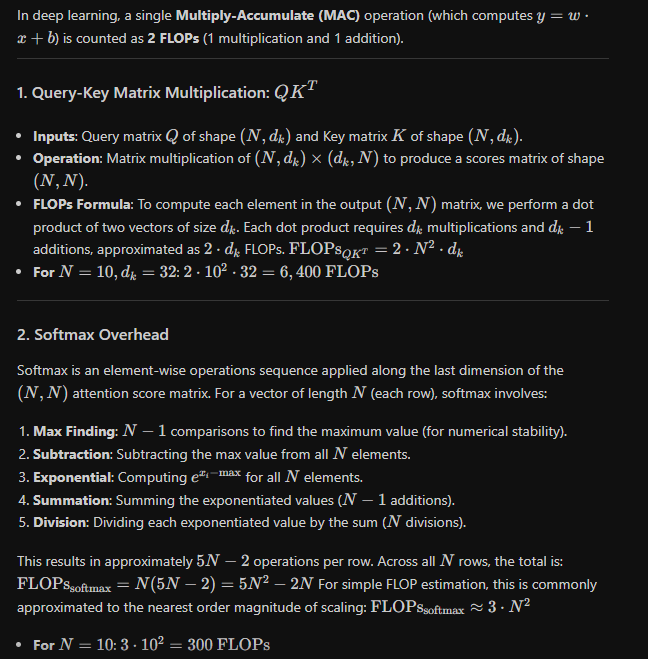
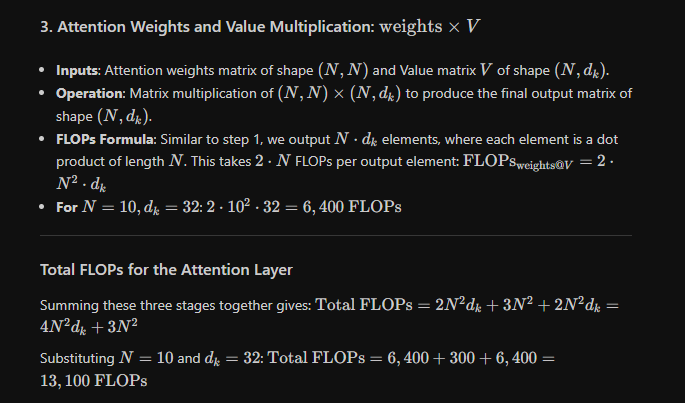